# Classify age group from resting-state brain connectivity

Resting-state **functional connectivity** summarizes how similar the activity is between different brain regions (ROIs) over time. A common representation is a correlation matrix: one row/column per ROI, and each entry is the correlation between two ROI time series.

In this notebook we will load a previously processed dataset containing connectivity matrices of 3 min. of resting state fMRI of young and adult humans. The **label** is which group the scan comes from (here we use two groups called **young** and **adult**).

In this notebook we will:
- look at the correlation matrices and basic summary plots
- turn each matrix into a numeric feature vector
- train a **Random Forest**

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree

RNG = 42
np.random.seed(RNG)

processed_data_path = Path("data/processed")

## Load windows from disk

Each saved window is a compressed NumPy file (`.npz`). We expect:

- `corr_matrix`: an \(R 	imes R\) correlation matrix (**symmetric**)
- `label`: `0` (**young**) or `1` (**adult**)

Below we read every matching file, skip invalid labels, and stack the results into lists.


In [2]:
def load_connectivity_windows(processed_dir: Path):
    """Return (matrices, labels) for all *_features.npz files we can read."""
    paths = sorted(processed_dir.glob("*_features.npz"))
    mats, y = [], []

    for path in paths:
        with np.load(path) as z:
            corr = np.asarray(z["corr_matrix"], dtype=np.float64)
            lab = int(np.ravel(z["label"])[0])

        if lab < 0:
            continue

        if corr.ndim != 2 or corr.shape[0] != corr.shape[1]:
            raise ValueError(f"Bad corr shape in {path.name}: {corr.shape}")

        mats.append(corr)
        y.append(lab)

    return mats, np.asarray(y, dtype=np.int64), paths


matrices, labels, file_paths = load_connectivity_windows(processed_data_path)

print(f"Windows loaded: {len(matrices)} | ROI count R = {matrices[0].shape[0]}" )
print("Young windows:", int(np.sum(labels == 0)), "| Adult windows:", int(np.sum(labels == 1)))


Windows loaded: 1612 | ROI count R = 96
Young windows: 884 | Adult windows: 728


## Explore the data before training

### Class balance

A quick count tells us whether the two groups are represented similarly. If one group is much smaller, accuracy can be misleading unless you also check per-class mistakes.


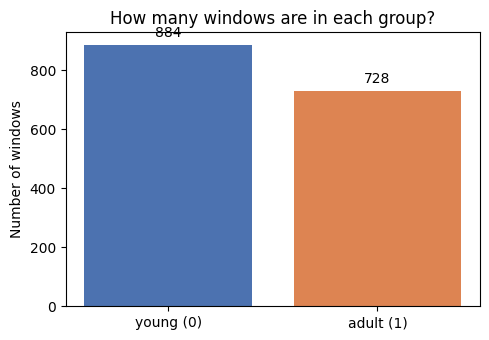

In [3]:
counts = np.bincount(labels, minlength=2)
names = ["young (0)", "adult (1)"]

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(names, counts, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Number of windows")
ax.set_title("How many windows are in each group?")
for i, v in enumerate(counts):
    ax.text(i, v + max(counts) * 0.02, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()


### Example correlation matrices

A correlation matrix often looks patterned: strong positive correlations along the diagonal (always 1) and structured off-diagonal entries that reflect networks in the brain (and noise).

Let's plot **one representative window per group**.


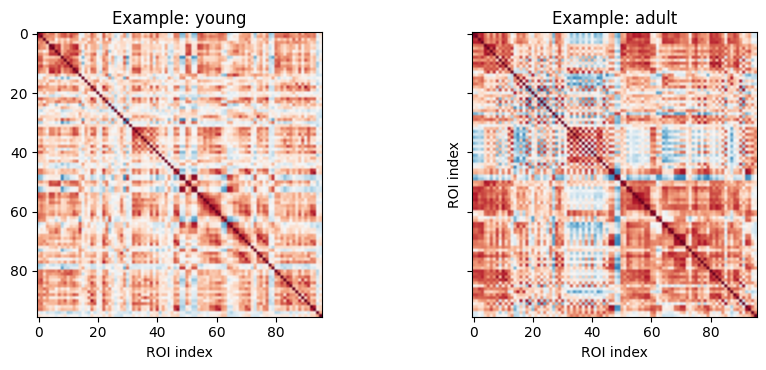

In [4]:
idx0 = int(np.flatnonzero(labels == 0)[0])
idx1 = int(np.flatnonzero(labels == 1)[0])

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)

for ax, idx, title in zip(
    axes,
    [idx0, idx1],
    ["Example: young", "Example: adult"],
):
    im = ax.imshow(matrices[idx], cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("ROI index")
ax.set_ylabel("ROI index")
plt.tight_layout()
plt.show()


### Average connectivity pattern per group

Averaging many correlation matrices removes some noise and makes group differences easier to see. This is only a **summary picture** — the classifier will use all windows, not just the average.


### Functional Connectome Visualization

Each ROI appears as a point at its atlas-based location, and **edges** curve between ROI pairs whose correlation survives a cutoff (below: strongest 10% by absolute correlation).

The atlas is loaded through Nilearn on an MNI grid resampled here to **3 mm** voxel spacing.

In the code cell below, adjust `WINDOW_INDEX` to visualize a different resting-state window.


[fetch_atlas_harvard_oxford] Dataset found in /root/nilearn_data/fsl

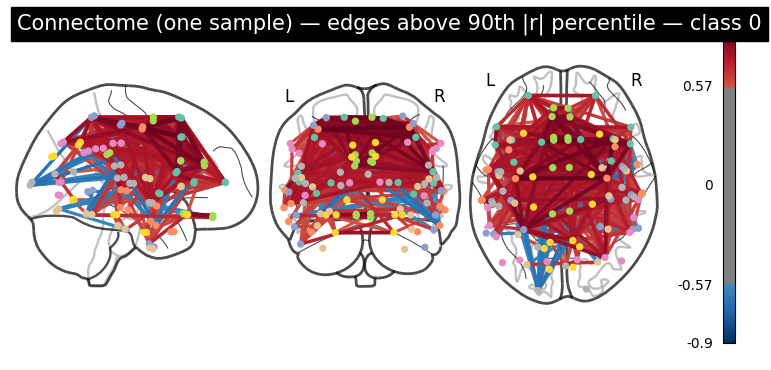

In [5]:
from nilearn import datasets, image
from nilearn import plotting as nl_plotting


def atlas_labels_image(target_mm: float = 3):
    """3D atlas image on an MNI grid with voxel spacing ``target_mm`` (millimeters)."""
    mni = datasets.load_mni152_template()
    orig_affine = mni.affine
    tgt_affine = orig_affine.copy()
    for axis in range(3):
        col = orig_affine[:3, axis]
        scale = np.linalg.norm(col)
        tgt_affine[:3, axis] = (col / scale) * target_mm

    ho = datasets.fetch_atlas_harvard_oxford(
        "cort-maxprob-thr25-2mm",
        symmetric_split=True,
    )
    return image.resample_img(
        ho.maps,
        target_affine=tgt_affine,
        interpolation="nearest",
    )


# Pick one resting-state window to visualize in atlas space (change the index to explore).
WINDOW_INDEX = 1
corr_one = matrices[WINDOW_INDEX].astype(float)
n_rois = corr_one.shape[0]

labels_img_atlas = atlas_labels_image(3)
node_coords = nl_plotting.find_parcellation_cut_coords(
    labels_img_atlas,
    background_label=0,
)

if node_coords.shape[0] != n_rois:
    print(
        "Skipping the glass-brain plot: the atlas has",
        node_coords.shape[0],
        "ROIs but this correlation matrix has",
        n_rois,
        "rows. The built-in synthetic demo uses a small toy size; use real",
        "atlas-sized correlation matrices to see the connectome.",
    )
else:
    adj = corr_one.copy()
    np.fill_diagonal(adj, 0)

    group = labels[WINDOW_INDEX]
    title = (
        "Connectome (one sample) — edges above 90th |r| percentile"
        f" — class {group}"
    )

    nl_plotting.plot_connectome(
        adj,
        node_coords,
        edge_threshold="90%",
        edge_cmap="RdBu_r",
        node_size=18,
        colorbar=True,
        title=title,
    )


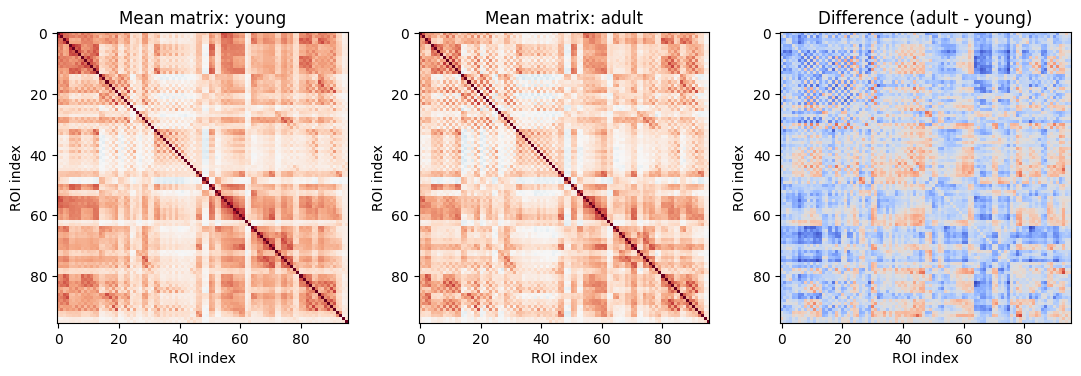

In [6]:
mean0 = np.mean([matrices[i] for i in np.flatnonzero(labels == 0)], axis=0)
mean1 = np.mean([matrices[i] for i in np.flatnonzero(labels == 1)], axis=0)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))

im_shared = None
for ax, mat, title in zip(
    axes[:2],
    [mean0, mean1],
    ["Mean matrix: young", "Mean matrix: adult"],
):
    im_shared = ax.imshow(mat, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("ROI index")
    ax.set_ylabel("ROI index")

absmax = float(np.max(np.abs(mean1 - mean0)))
absmax = max(absmax, 1e-6)

im_diff = axes[2].imshow(mean1 - mean0, cmap="coolwarm", vmin=-absmax, vmax=absmax)
axes[2].set_title("Difference (adult - young)")
axes[2].set_xlabel("ROI index")
axes[2].set_ylabel("ROI index")

plt.tight_layout()
plt.show()


### Distribution of pairwise correlations

Each window contributes many correlation values (all entries except the diagonal). Here we pool off-diagonal values (upper triangle only, to avoid counting each pair twice) and compare the two groups with histograms.


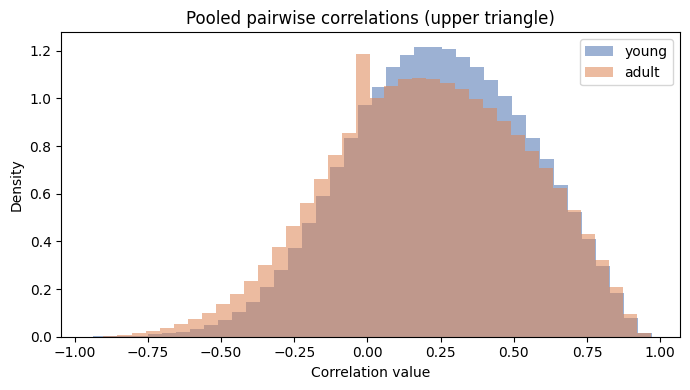

In [7]:
def upper_triangle_values(corr: np.ndarray) -> np.ndarray:
    i, j = np.triu_indices_from(corr, k=1)
    return corr[i, j]


vals0 = np.concatenate([upper_triangle_values(matrices[i]) for i in np.flatnonzero(labels == 0)])
vals1 = np.concatenate([upper_triangle_values(matrices[i]) for i in np.flatnonzero(labels == 1)])

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(vals0, bins=40, alpha=0.55, label="young", density=True, color="#4C72B0")
ax.hist(vals1, bins=40, alpha=0.55, label="adult", density=True, color="#DD8452")
ax.set_xlabel("Correlation value")
ax.set_ylabel("Density")
ax.set_title("Pooled pairwise correlations (upper triangle)")
ax.legend()
plt.tight_layout()
plt.show()


## Build the feature matrix

A Random Forest needs a 2D table `X` with shape `(n_windows, n_features)`.

We convert each \(R 	imes R\) matrix into one long vector by taking the **upper triangle without the diagonal**. The number of features is

\[
\frac{R(R-1)}{2},
\]

because each unordered pair \((i, j)\) appears once.


In [8]:
def corr_to_features(corr: np.ndarray) -> np.ndarray:
    i, j = np.triu_indices_from(corr, k=1)
    return corr[i, j].astype(np.float32)


X = np.stack([corr_to_features(c) for c in matrices], axis=0)
y = labels

n_features = X.shape[1]
print("X shape:", X.shape)
print("Feature count per window:", n_features)


X shape: (1612, 4560)
Feature count per window: 4560


## Train / test split

We randomly split **windows** into training and test sets. The model learns patterns on the training set and we measure performance on test windows.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RNG,
    stratify=y,
)

## Model Selection and training

In this case we choosed to use a random forest to classify young from adult given a correlation matrix. 

As the matrix is a 1D flattened set of features determining connectivity between regions, and the patterns to follow do not have to do with the space representation of them (being nearby does not mean being correlated), tipical models deep learning models using convolutions would fail to detect patterns, and logistic regression models would also fail to find a perfect courve that would separate the classes.

In contrast, a random forest is the perfect fit for this as its nature is to find patterns in this kind of data.

In [10]:
# Random forest from Scikit-Learn
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=16,
    min_samples_split=5,
    random_state=RNG,
    n_jobs=-1,
    class_weight="balanced",
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Test accuracy:", round(float(accuracy_score(y_test, y_pred)), 4))

Test accuracy: 0.9721


## Confusion matrix (test set)

The confusion matrix will provide a visual feedback of the performance of the model. As we validated it in a test subset that we did not use for training, we can be sure that the result provided is reliable.


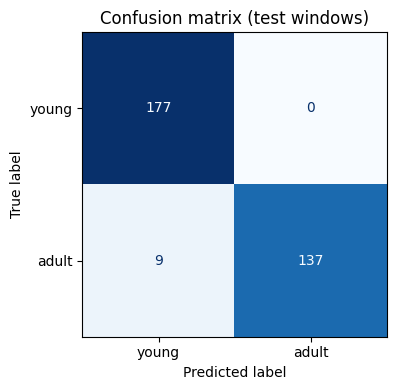

In [11]:
fig, ax = plt.subplots(figsize=(4.6, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["young", "adult"],
)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix (test windows)")
plt.tight_layout()
plt.show()


## Inside the forest (first few splits)

A Random Forest averages many decision trees.
We plot **one** tree and only show the **top few levels** so it fits on screen. In the picture, `X[i]` refers to the **i-th** feature in the vector we built from the upper triangle (the same order `np.triu_indices` uses).


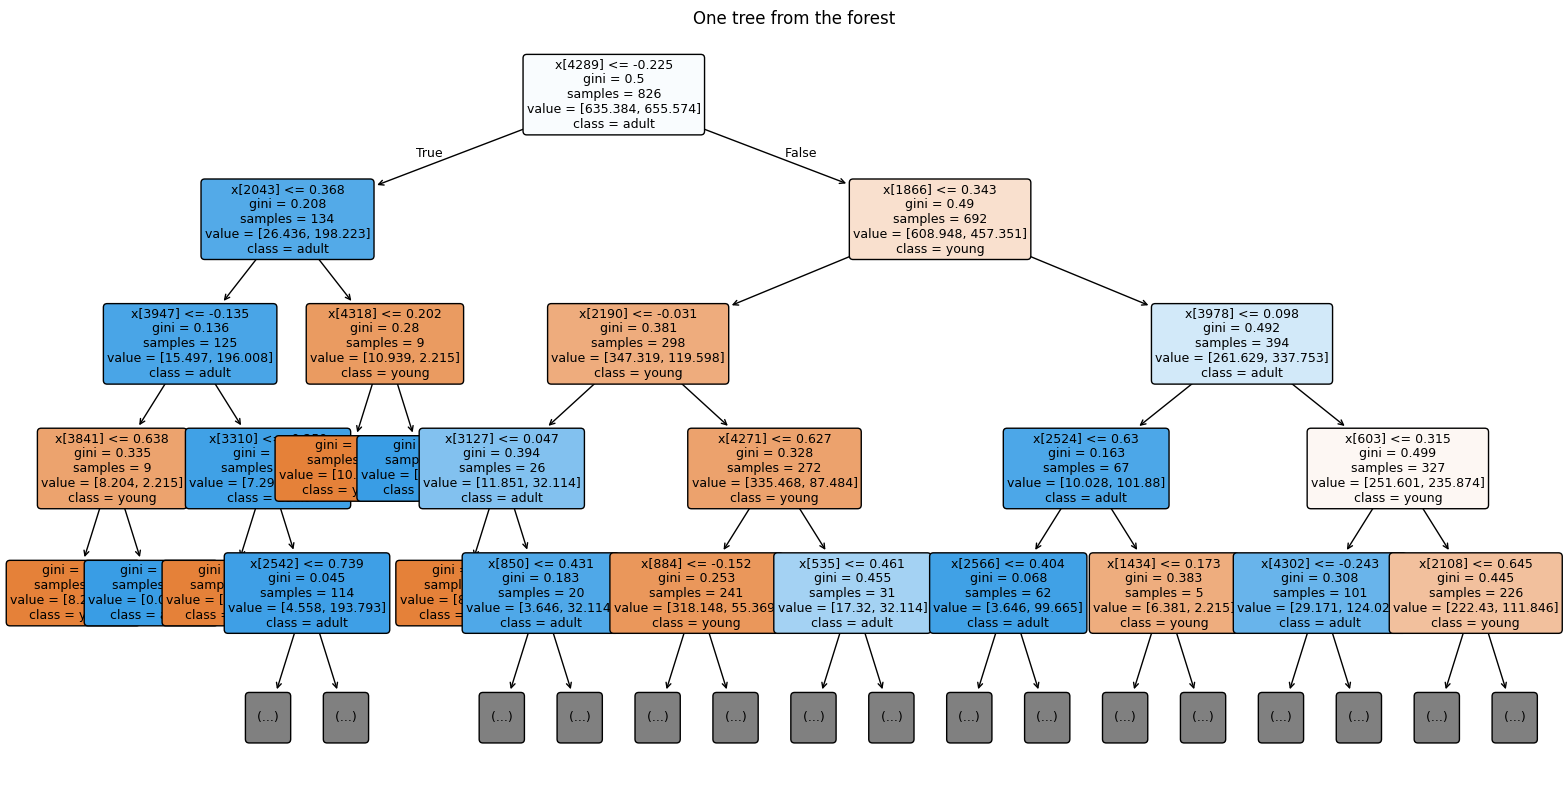

In [12]:
first_tree = model.estimators_[0]

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    first_tree,
    max_depth=4,
    feature_names=None,
    class_names=["young", "adult"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
ax.set_title("One tree from the forest")
plt.tight_layout()
plt.show()